# 2. starfold — validation

Notebook 1 produced a clustering. This notebook asks the two questions
that decide whether that clustering is worth trusting:

1. **Is any individual cluster above what random noise would produce?**
   Compare the per-cluster persistences to a noise null built by
   running the same pipeline on `n_realisations` shuffled Gaussian
   matrices of the same shape.
2. **Did the run as a whole "pass"?** `compute_credibility` runs a
   global 3σ test that combines three per-realisation scalars — the
   cluster count, the best Optuna objective, and the strongest cluster
   persistence — into a single pass/fail verdict.

The two single-call dashboards (`plot_tuning_dashboard`,
`plot_quality_dashboard`) provide the audit trail behind both answers.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "examples"))
from torus_chain import make_torus_chain  # noqa: E402

import starfold as sf  # noqa: E402
from starfold.plotting import (  # noqa: E402
    plot_credibility,
    plot_per_cluster_credibility,
    plot_persistence_vs_baseline,
)

FIGURE_DIR = Path("figures") / "tutorial_02_validation"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"starfold {sf.__version__}")

starfold 0.0.1


## 2.1 Fit with the noise baseline on

3 200-point torus chain (400 per ring × 8 rings). The pipeline now
receives a `noise_baseline_kwargs` block, which triggers a parallel
suite of fits on shuffled Gaussian realisations of shape `X.shape`.

The tutorial uses a deliberately small null (8 realisations ×
2 Optuna trials each, serial) so the notebook stays cheap to run in
a typical 8 GB RAM environment. For publication-quality thresholds
the paper uses 1 000 realisations with `n_jobs=-1` on a workstation;
the cache key is `(shape, umap_kwargs, random_state, n_realisations,
per_realisation_trials)` so the bigger run only happens once.

A subtle but important knob is the nested `umap_kwargs` override:
structureless Gaussian noise has no manifold to converge to, so 150
UMAP epochs are enough for the null fits even when the main fit
asks for more.

In [2]:
X, y_true = make_torus_chain(
    n_links=8,
    points_per_link=400,
    big_radius=4.0,
    major_even=2.0,
    major_odd=2.5,
    minor_radius=0.15,
    solid=True,
    noise_std=0.02,
    random_state=0,
)

pipeline = sf.UnsupervisedPipeline(
    umap_kwargs={"n_epochs": 400, "n_neighbors": 25, "min_dist": 0.0},
    hdbscan_optuna_trials=25,
    hdbscan_objective="combined_geom",
    mcs_range=(80, 500),
    ms_range=(5, 25),
    engine="cpu",
    skip_noise_baseline=False,
    random_state=0,
    noise_baseline_kwargs={
        "n_realisations": 8,
        "per_realisation_trials": 2,
        "percentile": 99.7,
        "n_jobs": 1,
        "umap_kwargs": {
            "n_neighbors": 25,
            "min_dist": 0.0,
            "n_epochs": 150,
        },
    },
)
t0 = time.perf_counter()
result = pipeline.fit(X)
print(f"pipeline.fit (with noise baseline) took {time.perf_counter() - t0:.1f}s")
print()
print(result.summary())

pipeline.fit (with noise baseline) took 32.8s

!! diagnostic flags
--------------------------------
- Optuna best was reached 20 trials before the end of the 25-trial budget; consider halving n_trials on similar runs to save compute.

starfold pipeline result
--------------------------------
n_samples        3200
n_clusters       9
n_outliers       0  (0.0%)
trustworthiness  0.9995
continuity       0.9977
objective        combined_geom
best_params      {'min_cluster_size': 171, 'min_samples': 16, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.21182739966945235, 'alpha': 1.1452086288497954}
persistence_sum  5.6470
persistence_med  0.7129
DBCV (MST proxy) 0.8630
noise_threshold  0.3874
significant      7/9
credibility      FAIL at alpha=0.003  p(n_clusters)=0.3333  p(combined_geom)=0.1111  p(max_persistence)=0.1111
per-cluster      0/9 clusters credible
persistence      [0.814 0.715 0.867 0.23  0.707 0.477 0.308 0.713 0.817]


/tmp/ipykernel_9788/567138667.py:35: UserWarning: Optuna best was reached 20 trials before the end of the 25-trial budget; consider halving n_trials on similar runs to save compute.
  result = pipeline.fit(X)


## 2.2 Per-cluster significance

The noise baseline returns a single scalar threshold: the 99.7th
percentile of the *maximum* cluster persistence across all shuffled
realisations. Any real cluster whose persistence exceeds it sits
above 3σ of structureless noise — the paper's operational definition
of "significant".

noise threshold (99.7 %) = 0.3874
null persistences: min = 0.099, median = 0.207, max = 0.391

cluster  persistence  > threshold
      0       0.8140          YES
      1       0.7149          YES
      2       0.8666          YES
      3       0.2305           no
      4       0.7069          YES
      5       0.4767          YES
      6       0.3080           no
      7       0.7129          YES
      8       0.8166          YES


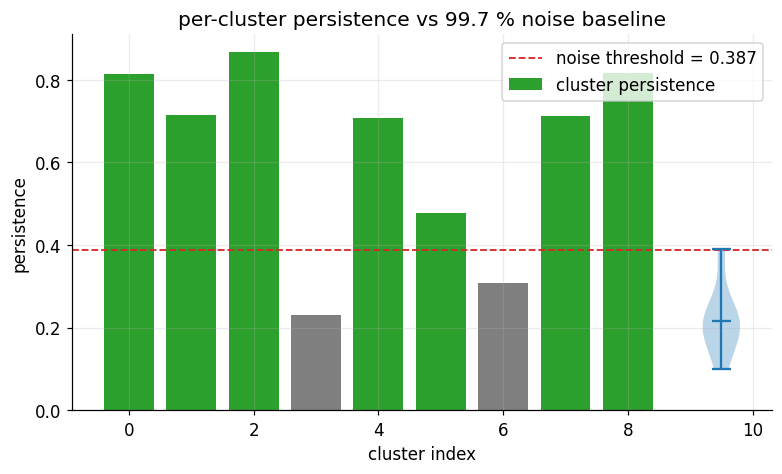

In [3]:
threshold = result.noise_baseline.threshold
per_real = result.noise_baseline.per_realisation_max
print(f"noise threshold (99.7 %) = {threshold:.4f}")
print(f"null persistences: min = {per_real.min():.3f}, "
      f"median = {np.median(per_real):.3f}, max = {per_real.max():.3f}")
print()
print(f"{'cluster':>7} {'persistence':>12} {'> threshold':>12}")
for k, p_k in enumerate(result.persistence):
    print(f"{k:>7d} {p_k:>12.4f} {'YES' if p_k > threshold else 'no':>12s}")

fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
plot_persistence_vs_baseline(
    result.persistence,
    baseline=threshold,
    per_realisation_max=per_real,
    ax=ax,
)
ax.set_title("per-cluster persistence vs 99.7 % noise baseline")
fig.savefig(FIGURE_DIR / "01_persistence_vs_baseline.png")
plt.show()

## 2.3 Global credibility (3σ)

Even on pure noise HDBSCAN will return at least two clusters, so
individual significance can still be misleading on a weak fit.
`compute_credibility` checks whether the run as a whole beats the
null across three axes:

* `n_clusters` — is more structure found than noise typically produces?
* `best_objective` — is Optuna's best score higher than the null's?
* `max_persistence` — is the strongest cluster stronger than any
  cluster noise ever produced?

A run "passes" at `alpha = 0.003` (3σ) when all three axes clear the
gate. Every real-data cluster also gets a per-cluster empirical
upper-tail p-value against the pool of every noise cluster's
persistence across every realisation, so clusters ship with
individual significance as well as the omnibus verdict.

credibility at alpha=0.003: FAIL
  n_clusters      obs=9  null-median=6  p=0.3333
  combined_geom   obs=0.7844  null-median=0.1019  p=0.1111
  max_persistence obs=0.8666  null-median=0.2065  p=0.1111
  per-cluster     0/9 clusters credible at alpha=0.003


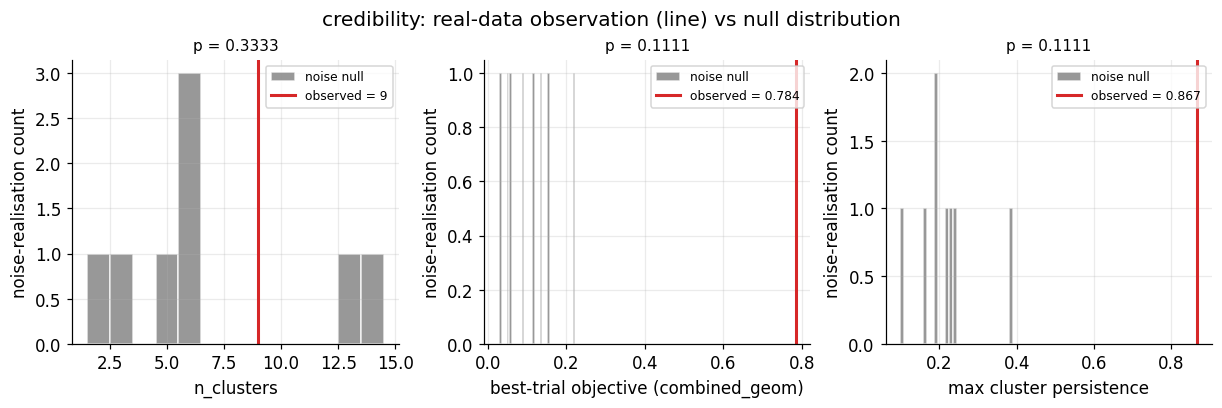

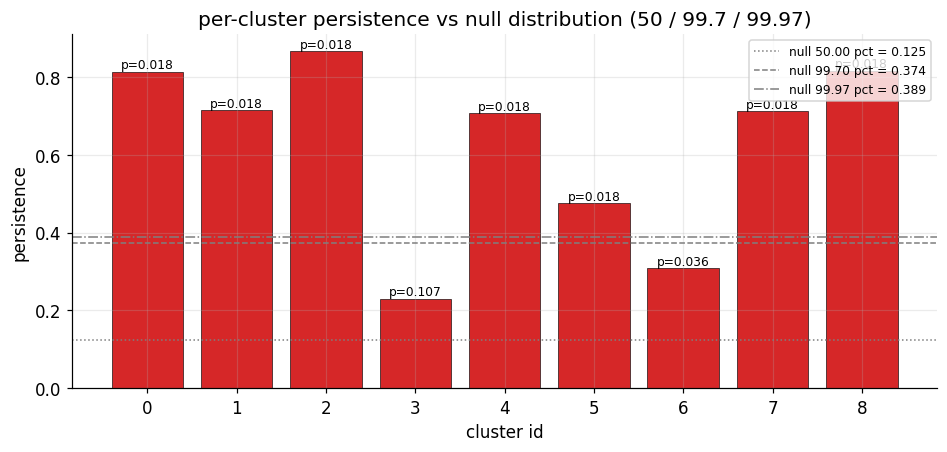

In [4]:
credibility = result.credibility
assert credibility is not None, "noise baseline was required for credibility"
print(credibility.summary())

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6), constrained_layout=True)
plot_credibility(credibility, axes=axes)
fig.suptitle("credibility: real-data observation (line) vs null distribution")
fig.savefig(FIGURE_DIR / "02_credibility_three_axes.png")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.0), constrained_layout=True)
plot_per_cluster_credibility(credibility, ax=ax)
ax.set_title("per-cluster persistence vs null distribution (50 / 99.7 / 99.97)")
fig.savefig(FIGURE_DIR / "03_per_cluster_credibility.png")
plt.show()

## 2.4 Tuning dashboard — *did Optuna find a good minimum?*

Eight panels of Optuna search diagnostics on one figure:

* **(a)** running-best objective over trials,
* **(b-c)** Pareto fronts of persistence sum / median against DBCV,
* **(d)** the `(min_cluster_size, min_samples)` landscape,
* **(e)** the granularity-stability trade-off,
* **(f)** parallel coordinates over the full search,
* **(g)** HDBSCAN's condensed tree for the selected fit,
* **(h)** fANOVA parameter importance.

A star in every panel marks the trial Optuna picked.

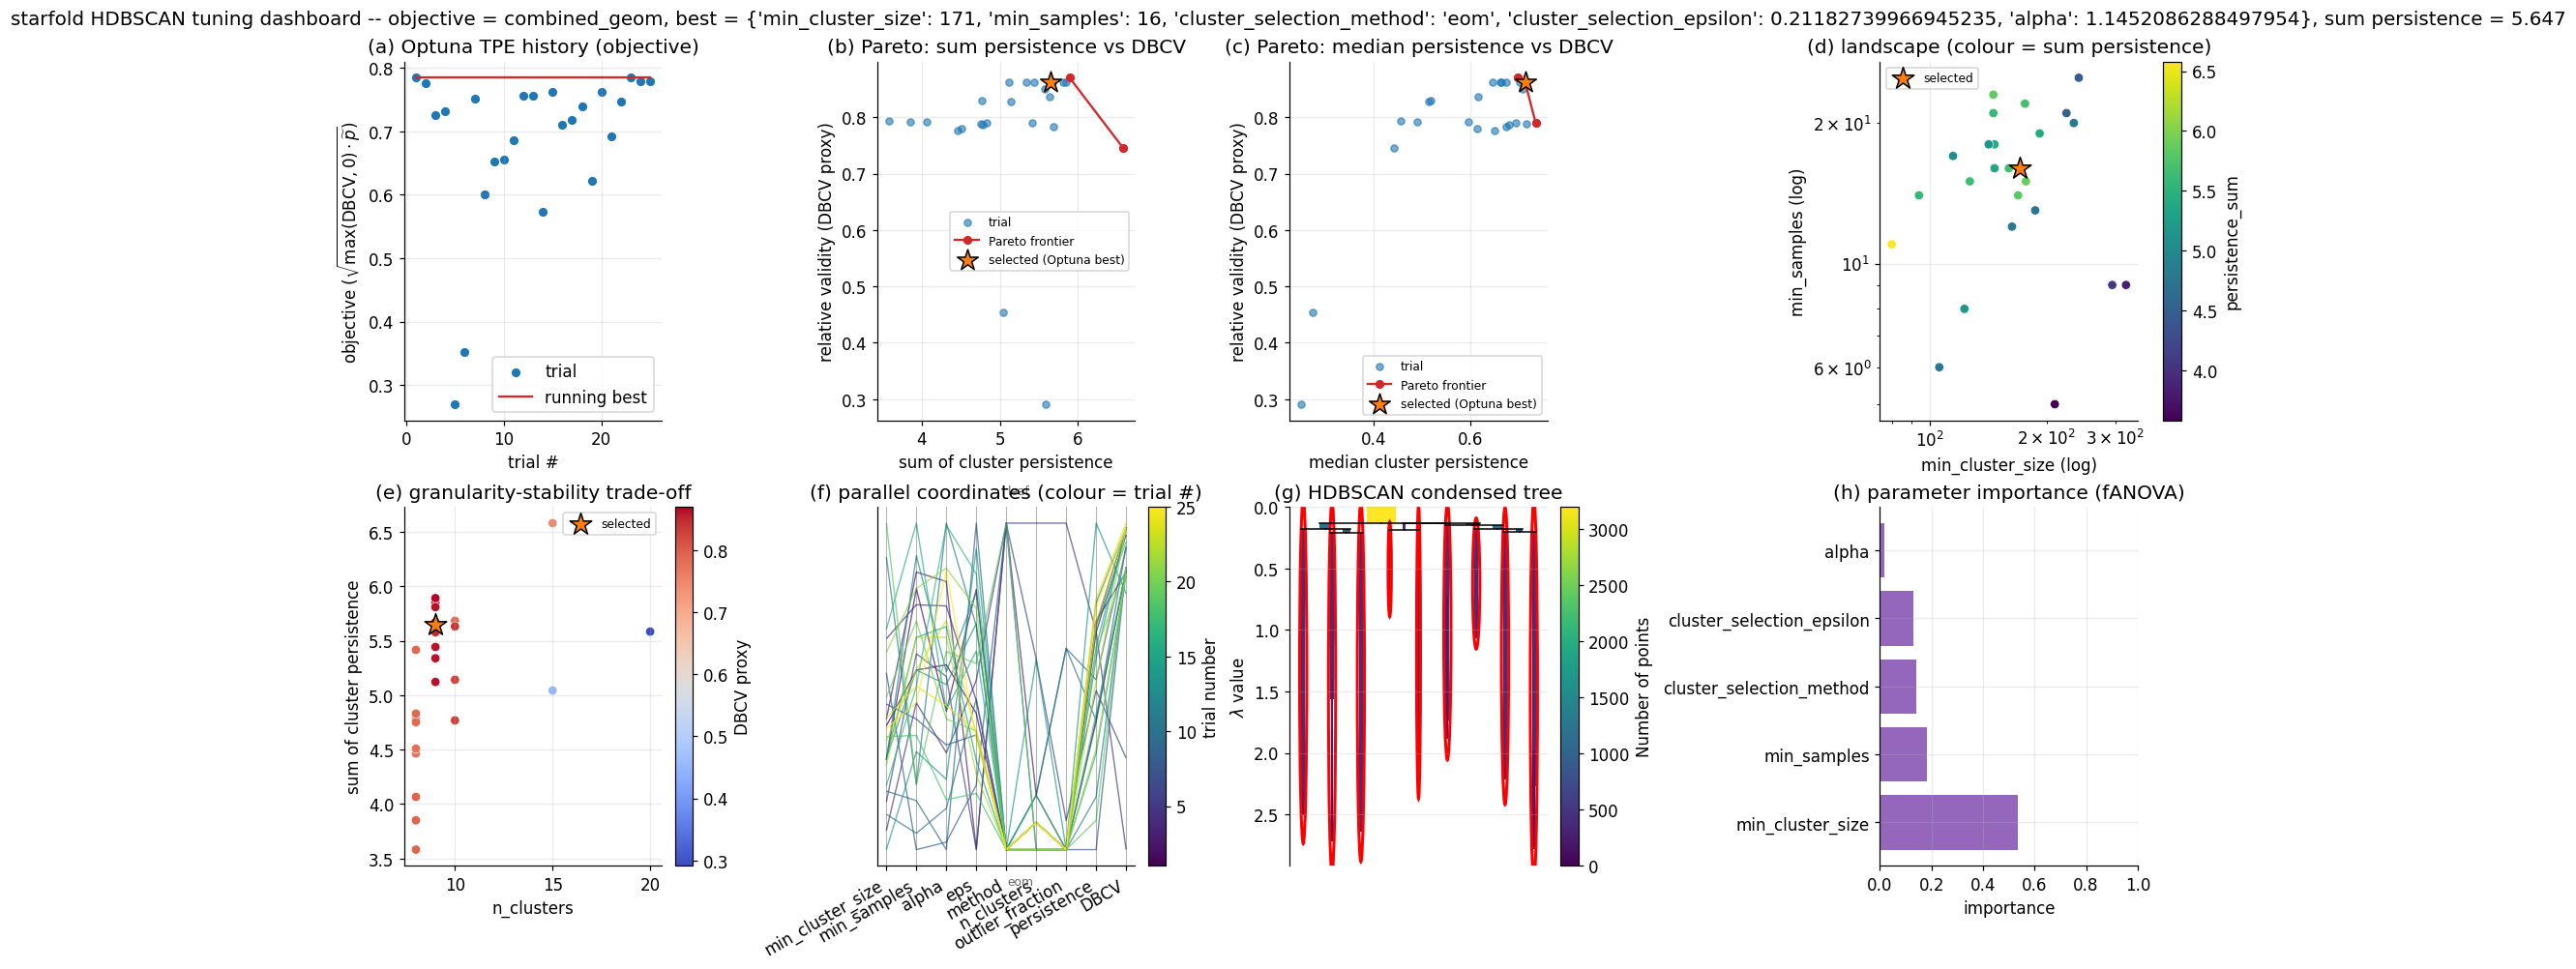

In [5]:
fig = result.plot_tuning_dashboard(figsize=(18.0, 9.0))
fig.savefig(FIGURE_DIR / "04_tuning_dashboard.png")
plt.show()

## 2.5 Quality dashboard — *is the result stable?*

The tuning dashboard asked *did the search converge?*. This one asks
*does the winning configuration reproduce itself under perturbation?*.
It re-runs the selected HDBSCAN on 20 random 80 % subsamples and
tracks cluster count + ARI against the full-sample labelling. Stable
cluster counts and ARI close to 1 mean the structure is robust.

The top row adds the membership-probability map, fANOVA importance,
and the trustworthiness T(k) / continuity C(k) curves — reporting
both catches failure modes either alone would miss.

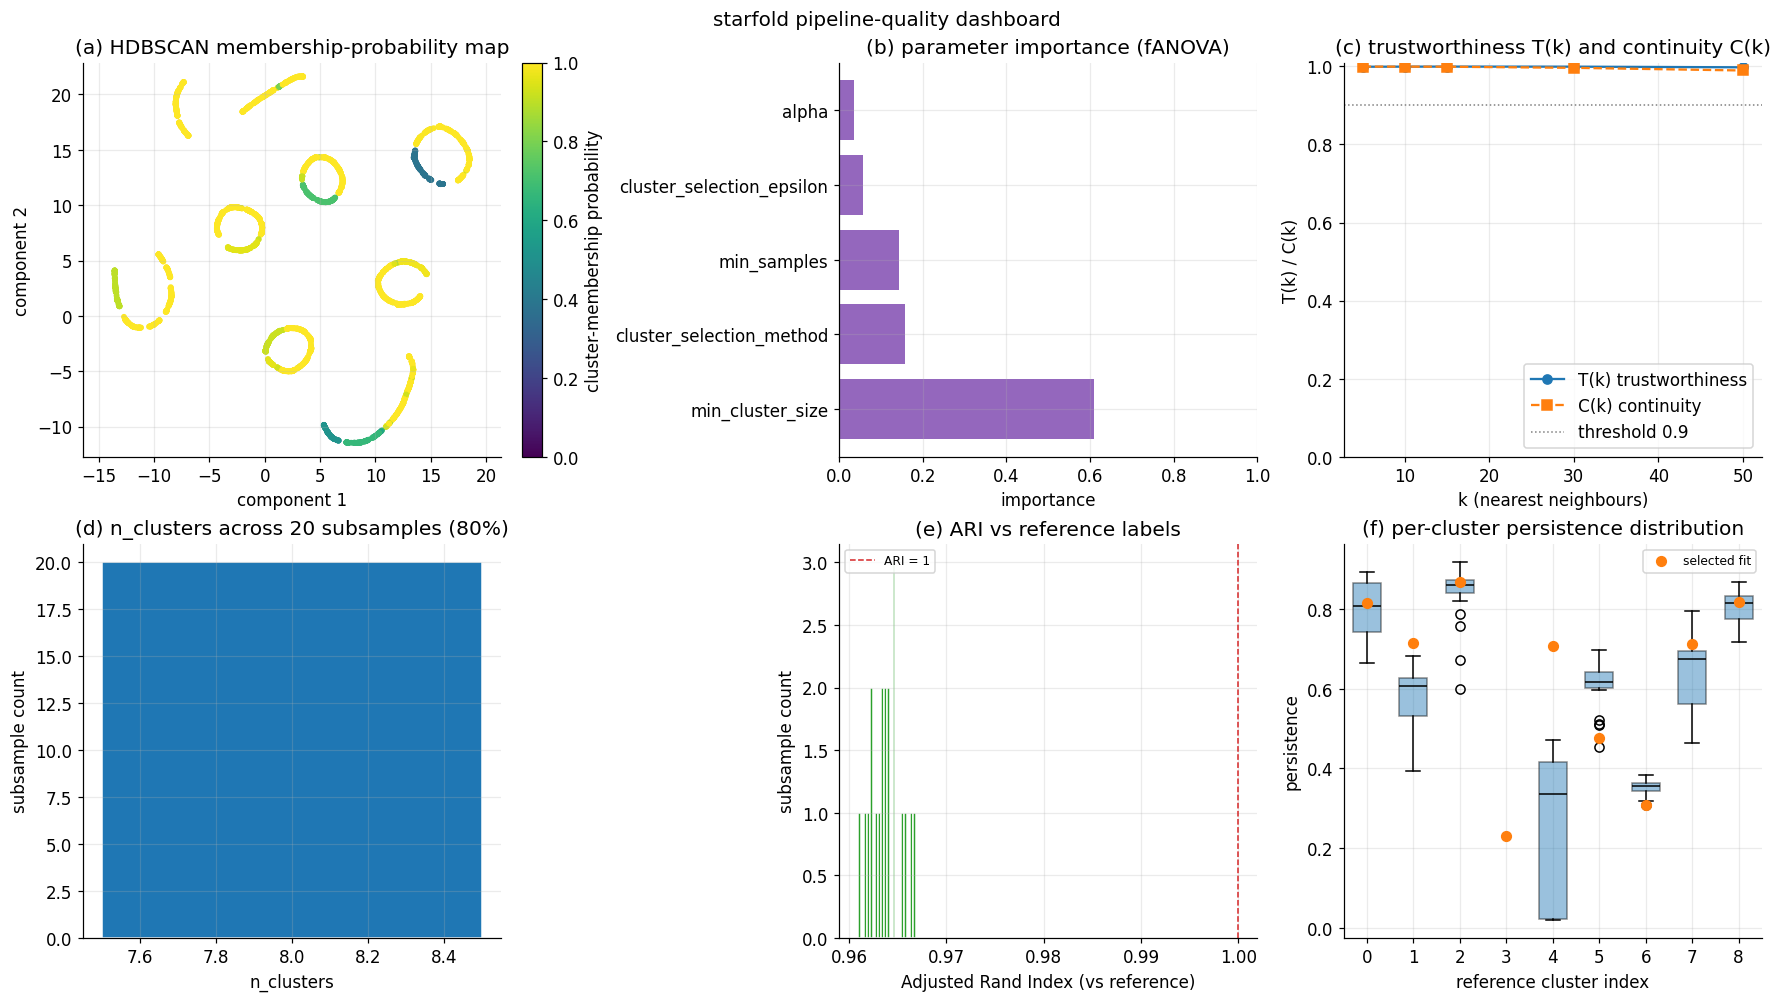

In [6]:
fig = result.plot_quality_dashboard(
    X,
    n_subsamples=20,
    subsample_fraction=0.8,
    k_values=(5, 10, 15, 30, 50),
    figsize=(16.0, 9.0),
    random_state=0,
)
fig.savefig(FIGURE_DIR / "05_quality_dashboard.png")
plt.show()

## 2.6 Takeaways

* `noise_baseline_kwargs` flips the per-cluster significance gate on.
  The cache keys on the hash of shape + UMAP kwargs, so re-running
  the notebook is free once the baseline is built.
* `compute_credibility` is the omnibus 3σ test — cheap because it
  reuses the noise baseline.
* `plot_tuning_dashboard` and `plot_quality_dashboard` are the two
  one-line audit panels. Save them next to every run.

Next up: **[3. Refinement](tutorial_03_advanced.ipynb)** — what to
do once you trust the clustering.